<a href="https://colab.research.google.com/github/gustavo-mrcbg/app-ideas/blob/master/MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical


Loads the dataset

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess data
# 1. Reshape to (28, 28, 1) and normalize pixel values to [0, 1]
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# 2. One-hot encode labels (e.g., "3" becomes [0,0,0,1,0,0,0,0,0,0])
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build the Model

In [ ]:
# Build the CNN model
model = Sequential([
    # Convolutional Layer 1: 32 filters, 3x3 kernel, ReLU activation
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Max Pooling Layer 1: 2x2 pool size
    MaxPooling2D((2, 2)),

    # Convolutional Layer 2: 64 filters, 3x3 kernel, ReLU activation
    Conv2D(64, (3, 3), activation='relu'),
    # Max Pooling Layer 2: 2x2 pool size
    MaxPooling2D((2, 2)),

    # Flatten the output for dense layers
    Flatten(),

    # Fully Connected Layer: 128 neurons, ReLU activation
    Dense(128, activation='relu'),

    # Output Layer: 10 neurons (for 10 digits), softmax activation
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train the model

In [ ]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=12,
                    batch_size=64,
                    validation_split=0.2)


Epoch 1/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9948 - loss: 0.0161 - val_accuracy: 0.9887 - val_loss: 0.0415
Epoch 2/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9961 - loss: 0.0113 - val_accuracy: 0.9902 - val_loss: 0.0358
Epoch 3/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.9974 - loss: 0.0085 - val_accuracy: 0.9902 - val_loss: 0.0407
Epoch 4/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.9979 - loss: 0.0070 - val_accuracy: 0.9896 - val_loss: 0.0404
Epoch 5/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9976 - loss: 0.0078 - val_accuracy: 0.9905 - val_loss: 0.0423
Epoch 6/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9981 - loss: 0.0067 - val_accuracy: 0.9896 - val_loss: 0.0476
Epoch 7/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9983 - loss: 0.0047 - val_accuracy: 0.9898 - val_loss: 0.0452
Epoch 8/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9982 - loss: 0.0047 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9891 - loss: 0.0579
Test Accuracy: 99.09%


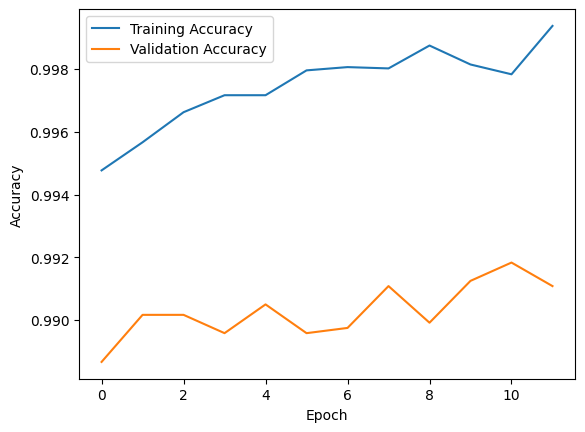

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()